# Shehab Modelling Notebook: Logistic Regression and Random Forest

This notebook trains and evaluates Shehab's assigned fraud detection models using the shared processed datasets. Logistic Regression is used as the shared model variant, and Random Forest is used as the individual model.

## 1. Import Libraries

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

## 2. Load Project Helpers

The notebook uses the shared evaluation function so Shehab's results match the locked group schema.

In [2]:
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import DATA_PROCESSED_DIR, OUTPUT_FIGURES_DIR, OUTPUT_RESULTS_DIR, RANDOM_STATE
from src.evaluation import evaluate_model_full, recall_at_precision, tune_threshold_f1
from src.plotting import plot_confusion_matrix, plot_precision_recall_curve, plot_roc_curve

## 3. Configuration

In [3]:
MEMBER = "Shehab"
TARGET_COLUMN = "is_fraud"
RESULTS_SCHEMA = [
    "member",
    "model",
    "split",
    "imbalance_strategy",
    "threshold",
    "pr_auc",
    "roc_auc",
    "mcc",
    "recall_at_90p",
    "f1",
    "precision",
    "recall",
    "fpr",
    "accuracy",
    "tp",
    "fp",
    "fn",
    "tn",
]

TRAIN_PATH = DATA_PROCESSED_DIR / "train_processed.csv"
VAL_PATH = DATA_PROCESSED_DIR / "val_processed.csv"
TEST_PATH = DATA_PROCESSED_DIR / "test_processed.csv"

OUTPUT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Processed data directory: {DATA_PROCESSED_DIR.relative_to(PROJECT_ROOT)}")
print(f"Results directory: {OUTPUT_RESULTS_DIR.relative_to(PROJECT_ROOT)}")
print(f"Figures directory: {OUTPUT_FIGURES_DIR.relative_to(PROJECT_ROOT)}")

Processed data directory: data\processed
Results directory: outputs\results
Figures directory: outputs\figures


## 4. Load Processed Datasets

The group preprocessing notebook should create the train, validation, and test CSV files before this notebook is run.

In [4]:
required_files = [TRAIN_PATH, VAL_PATH, TEST_PATH]
missing_files = [path for path in required_files if not path.exists()]

if missing_files:
    missing = ", ".join(str(path.relative_to(PROJECT_ROOT)) for path in missing_files)
    raise FileNotFoundError(f"Missing processed dataset file(s): {missing}")

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")
display(train_df.head())

Train shape: (198608, 38)
Validation shape: (42559, 38)
Test shape: (42559, 38)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,Amount,hour_of_day,day_number,is_night,is_business_hours,log_amount,amount_band_encoded,is_small_amount,is_round_amount,Class
0,2.139297,-2.379957,-0.588094,-2.116887,-0.151810,4.930636,-3.133495,1.408309,0.431508,1.189920,...,-0.308400,0.848971,1.014904,0,0,-0.291051,1,0,0,0
1,-2.150992,0.447565,0.584405,1.181052,0.180772,-1.200828,-0.106578,0.771604,-1.441208,-0.481802,...,-0.363961,1.020523,-0.985315,0,0,-1.893796,0,1,0,0
2,-6.000510,-5.868708,-1.210423,2.234168,-0.925608,0.019870,0.012067,0.910109,-0.905567,0.233812,...,1.876398,1.192075,-0.985315,0,0,1.898296,2,0,0,0
3,2.021325,-0.535640,-0.416146,-0.124310,-0.178832,0.918878,-1.042599,0.318182,1.072180,0.119271,...,-0.359922,-1.038106,1.014904,0,0,-1.487218,0,1,1,0
4,0.149536,0.807852,-0.590906,-0.509802,1.145394,-1.116329,0.935687,-0.234237,0.014499,-1.110721,...,-0.344877,-0.866554,1.014904,0,1,-0.860146,0,1,0,0


## 5. Define X and y

In [5]:
target_alias = "Class"
for split_name, split_df in {"train": train_df, "validation": val_df, "test": test_df}.items():
    if TARGET_COLUMN not in split_df.columns and target_alias in split_df.columns:
        split_df.rename(columns={target_alias: TARGET_COLUMN}, inplace=True)
    if TARGET_COLUMN not in split_df.columns:
        raise ValueError(f"{split_name} data does not contain the target column '{TARGET_COLUMN}'.")

X_train = train_df.drop(columns=[TARGET_COLUMN])
y_train = train_df[TARGET_COLUMN].astype(int)

X_val = val_df.drop(columns=[TARGET_COLUMN])
y_val = val_df[TARGET_COLUMN].astype(int)

X_test = test_df.drop(columns=[TARGET_COLUMN])
y_test = test_df[TARGET_COLUMN].astype(int)

non_numeric = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    raise ValueError(f"Non-numeric feature columns remain after preprocessing: {non_numeric}")

class_balance = pd.DataFrame({
    "train": y_train.value_counts().sort_index(),
    "validation": y_val.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index(),
}).fillna(0).astype(int)

display(class_balance)
print(f"Number of features: {X_train.shape[1]}")

,train,validation,test
is_fraud,,,
0,198277,42488,42488
1,331,71,71


Number of features: 37


## 6. Evaluation Framing

Fraud detection is highly imbalanced, so PR-AUC is especially useful because it focuses on the minority fraud class rather than being dominated by genuine transactions. MCC is also useful as a single-measure check because it considers all four confusion-matrix outcomes and is less misleading when classes are uneven.

Recall at 90% precision estimates how much fraud could be captured while keeping false alarms relatively controlled. In operations, this helps frame whether a model is suitable for review queues, step-up authentication, or direct blocking thresholds.

## 7. Modelling Utilities

In [6]:
def get_cv_splits(y, max_splits=3):
    min_class_count = int(y.value_counts().min())
    if min_class_count < 2:
        raise ValueError("At least two examples of each class are needed for cross-validation.")
    return min(max_splits, min_class_count)


def get_smote():
    minority_count = int(y_train.value_counts().min())
    k_neighbors = min(5, minority_count - 1)
    if k_neighbors < 1:
        raise ValueError("SMOTE needs at least two minority-class training examples.")
    return SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors)


def make_log_reg_pipeline(imbalance_strategy, C=1.0):
    class_weight = "balanced" if imbalance_strategy == "balanced" else None
    steps = [("scaler", StandardScaler())]
    if imbalance_strategy == "smote":
        steps.append(("smote", get_smote()))
    steps.append((
        "model",
        LogisticRegression(
            penalty="l2",
            C=C,
            solver="liblinear",
            class_weight=class_weight,
            max_iter=1000,
            random_state=RANDOM_STATE,
        ),
    ))
    return ImbPipeline(steps)


def make_random_forest_pipeline(imbalance_strategy, **params):
    class_weight = "balanced" if imbalance_strategy == "balanced" else None
    model_params = {
        "n_estimators": 150,
        "class_weight": class_weight,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }
    model_params.update(params)

    steps = []
    if imbalance_strategy == "smote":
        steps.append(("smote", get_smote()))
    steps.append(("model", RandomForestClassifier(**model_params)))
    return ImbPipeline(steps)


def positive_class_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    raise TypeError("Model does not provide probability scores or decision scores.")


def validation_result(model_name, imbalance_strategy, model):
    y_val_score = positive_class_scores(model, X_val)
    threshold, _ = tune_threshold_f1(y_val, y_val_score)
    return evaluate_model_full(
        model_name=model_name,
        member=MEMBER,
        split="validation",
        imbalance_strategy=imbalance_strategy,
        y_true=y_val,
        y_score=y_val_score,
        threshold=threshold,
    )


cv_splits = get_cv_splits(y_train)
imbalance_strategies = ["none", "balanced", "smote"]
fitted_models = {}
validation_rows = []

print(f"Cross-validation folds: {cv_splits}")

Cross-validation folds: 3


## 8. Logistic Regression Strengths and Weaknesses

Logistic Regression is a strong baseline for fraud detection because it is fast, transparent, and produces calibrated-style probability scores that are easy to threshold. Its main limitation is that it may miss complex non-linear transaction patterns unless feature engineering captures those patterns well.

## 9. Baseline Logistic Regression

In [7]:
baseline_lr = make_log_reg_pipeline("none", C=1.0)
baseline_lr.fit(X_train, y_train)

model_key = ("Logistic Regression Baseline", "none")
fitted_models[model_key] = baseline_lr
validation_rows.append(validation_result(*model_key, baseline_lr))

display(pd.DataFrame([validation_rows[-1]])[RESULTS_SCHEMA])

,member,model,split,imbalance_strategy,threshold,pr_auc,roc_auc,mcc,recall_at_90p,f1,precision,recall,fpr,accuracy,tp,fp,fn,tn
0,Shehab,Logistic Regression Baseline,validation,none,0.059511,0.703154,0.971101,0.788507,0.112676,0.788321,0.818182,0.760563,0.000282,0.999319,54,12,17,42476


## 10. Tuned Logistic Regression: L2, C=1.0

This is Shehab's shared model variant. The regularisation setting is fixed at L2 with C=1.0, while imbalance handling is compared across the three agreed strategies.

In [8]:
for strategy in imbalance_strategies:
    lr_search = GridSearchCV(
        estimator=make_log_reg_pipeline(strategy, C=1.0),
        param_grid={"model__C": [1.0], "model__penalty": ["l2"]},
        scoring="average_precision",
        cv=cv_splits,
        n_jobs=-1,
    )
    lr_search.fit(X_train, y_train)

    model_name = "Logistic Regression L2 C=1.0"
    model_key = (model_name, strategy)
    fitted_models[model_key] = lr_search.best_estimator_
    validation_rows.append(validation_result(model_name, strategy, lr_search.best_estimator_))

log_reg_results = pd.DataFrame(validation_rows)[RESULTS_SCHEMA]
display(log_reg_results[log_reg_results["model"].str.contains("Logistic Regression")])

,member,model,split,imbalance_strategy,threshold,pr_auc,roc_auc,mcc,recall_at_90p,f1,precision,recall,fpr,accuracy,tp,fp,fn,tn
0,Shehab,Logistic Regression Baseline,validation,none,0.059511,0.703154,0.971101,0.788507,0.112676,0.788321,0.818182,0.760563,0.000282,0.999319,54,12,17,42476
1,Shehab,Logistic Regression L2 C=1.0,validation,none,0.059511,0.703154,0.971101,0.788507,0.112676,0.788321,0.818182,0.760563,0.000282,0.999319,54,12,17,42476
2,Shehab,Logistic Regression L2 C=1.0,validation,balanced,1.000000,0.720429,0.972955,0.835484,0.774648,0.833333,0.901639,0.774648,0.000141,0.999483,55,6,16,42482
3,Shehab,Logistic Regression L2 C=1.0,validation,smote,1.000000,0.714072,0.973472,0.842434,0.774648,0.839695,0.916667,0.774648,0.000118,0.999507,55,5,16,42483


## 11. Random Forest Strengths and Weaknesses

Random Forest can capture non-linear relationships and feature interactions that may be useful in transaction risk modelling. Its weaknesses are reduced interpretability compared with Logistic Regression, higher computational cost, and the risk of overfitting if model complexity is not controlled.

## 12. Baseline Random Forest

In [9]:
baseline_rf = make_random_forest_pipeline("none")
baseline_rf.fit(X_train, y_train)

model_key = ("Random Forest Baseline", "none")
fitted_models[model_key] = baseline_rf
validation_rows.append(validation_result(*model_key, baseline_rf))

display(pd.DataFrame([validation_rows[-1]])[RESULTS_SCHEMA])

,member,model,split,imbalance_strategy,threshold,pr_auc,roc_auc,mcc,recall_at_90p,f1,precision,recall,fpr,accuracy,tp,fp,fn,tn
0,Shehab,Random Forest Baseline,validation,none,0.446667,0.819945,0.926844,0.88011,0.802817,0.875,0.982456,0.788732,0.000024,0.999624,56,1,15,42487


## 13. Tuned Random Forest

The search space is intentionally small so the notebook remains practical on a normal laptop.

In [10]:
rf_param_distributions = {
    "model__n_estimators": [150, 250, 350],
    "model__max_depth": [None, 8, 12, 16],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

for strategy in imbalance_strategies:
    rf_search = RandomizedSearchCV(
        estimator=make_random_forest_pipeline(strategy),
        param_distributions=rf_param_distributions,
        n_iter=4,
        scoring="average_precision",
        cv=cv_splits,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf_search.fit(X_train, y_train)

    model_name = "Random Forest Tuned"
    model_key = (model_name, strategy)
    fitted_models[model_key] = rf_search.best_estimator_
    validation_rows.append(validation_result(model_name, strategy, rf_search.best_estimator_))

rf_results = pd.DataFrame(validation_rows)[RESULTS_SCHEMA]
display(rf_results[rf_results["model"].str.contains("Random Forest")].sort_values("pr_auc", ascending=False))

,member,model,split,imbalance_strategy,threshold,pr_auc,roc_auc,mcc,recall_at_90p,f1,precision,recall,fpr,accuracy,tp,fp,fn,tn
6,Shehab,Random Forest Tuned,validation,balanced,0.279709,0.853797,0.943996,0.873123,0.830986,0.870229,0.950000,0.802817,0.000071,0.999601,57,3,14,42485
7,Shehab,Random Forest Tuned,validation,smote,0.415414,0.838802,0.964973,0.867012,0.816901,0.865672,0.920635,0.816901,0.000118,0.999577,58,5,13,42483
5,Shehab,Random Forest Tuned,validation,none,0.438965,0.822753,0.967802,0.880110,0.802817,0.875000,0.982456,0.788732,0.000024,0.999624,56,1,15,42487
4,Shehab,Random Forest Baseline,validation,none,0.446667,0.819945,0.926844,0.880110,0.802817,0.875000,0.982456,0.788732,0.000024,0.999624,56,1,15,42487


## 14. Validation Model Comparison

The decision threshold is tuned on validation data only. The final test set is not used for model selection.

In [11]:
validation_results_df = pd.DataFrame(validation_rows)[RESULTS_SCHEMA]
validation_results_df = validation_results_df.sort_values(
    ["pr_auc", "mcc", "recall_at_90p"],
    ascending=False,
).reset_index(drop=True)

display(validation_results_df)

,member,model,split,imbalance_strategy,threshold,pr_auc,roc_auc,mcc,recall_at_90p,f1,precision,recall,fpr,accuracy,tp,fp,fn,tn
0,Shehab,Random Forest Tuned,validation,balanced,0.279709,0.853797,0.943996,0.873123,0.830986,0.870229,0.950000,0.802817,0.000071,0.999601,57,3,14,42485
1,Shehab,Random Forest Tuned,validation,smote,0.415414,0.838802,0.964973,0.867012,0.816901,0.865672,0.920635,0.816901,0.000118,0.999577,58,5,13,42483
2,Shehab,Random Forest Tuned,validation,none,0.438965,0.822753,0.967802,0.880110,0.802817,0.875000,0.982456,0.788732,0.000024,0.999624,56,1,15,42487
3,Shehab,Random Forest Baseline,validation,none,0.446667,0.819945,0.926844,0.880110,0.802817,0.875000,0.982456,0.788732,0.000024,0.999624,56,1,15,42487
4,Shehab,Logistic Regression L2 C=1.0,validation,balanced,1.000000,0.720429,0.972955,0.835484,0.774648,0.833333,0.901639,0.774648,0.000141,0.999483,55,6,16,42482
5,Shehab,Logistic Regression L2 C=1.0,validation,smote,1.000000,0.714072,0.973472,0.842434,0.774648,0.839695,0.916667,0.774648,0.000118,0.999507,55,5,16,42483
6,Shehab,Logistic Regression Baseline,validation,none,0.059511,0.703154,0.971101,0.788507,0.112676,0.788321,0.818182,0.760563,0.000282,0.999319,54,12,17,42476
7,Shehab,Logistic Regression L2 C=1.0,validation,none,0.059511,0.703154,0.971101,0.788507,0.112676,0.788321,0.818182,0.760563,0.000282,0.999319,54,12,17,42476


## 15. Select Final Model from Validation Data

In [12]:
selected_row = validation_results_df.iloc[0]
selected_key = (selected_row["model"], selected_row["imbalance_strategy"])
selected_model = fitted_models[selected_key]
selected_threshold = float(selected_row["threshold"])

print(f"Selected model: {selected_key[0]}")
print(f"Selected imbalance strategy: {selected_key[1]}")
print(f"Validation-tuned threshold: {selected_threshold:.6f}")

Selected model: Random Forest Tuned
Selected imbalance strategy: balanced
Validation-tuned threshold: 0.279709


## 16. Final Test Evaluation

The selected validation threshold is applied to the test set once for final reporting.

In [13]:
test_scores = positive_class_scores(selected_model, X_test)
test_row = evaluate_model_full(
    model_name=selected_key[0],
    member=MEMBER,
    split="test",
    imbalance_strategy=selected_key[1],
    y_true=y_test,
    y_score=test_scores,
    threshold=selected_threshold,
)

results_df = pd.concat(
    [validation_results_df, pd.DataFrame([test_row])],
    ignore_index=True,
)[RESULTS_SCHEMA]

results_path = OUTPUT_RESULTS_DIR / "results_shehab.csv"
results_df.to_csv(results_path, index=False)

print(f"Saved results to {results_path.relative_to(PROJECT_ROOT)}")
display(results_df)

Saved results to outputs\results\results_shehab.csv


,member,model,split,imbalance_strategy,threshold,pr_auc,roc_auc,mcc,recall_at_90p,f1,precision,recall,fpr,accuracy,tp,fp,fn,tn
0,Shehab,Random Forest Tuned,validation,balanced,0.279709,0.853797,0.943996,0.873123,0.830986,0.870229,0.950000,0.802817,0.000071,0.999601,57,3,14,42485
1,Shehab,Random Forest Tuned,validation,smote,0.415414,0.838802,0.964973,0.867012,0.816901,0.865672,0.920635,0.816901,0.000118,0.999577,58,5,13,42483
2,Shehab,Random Forest Tuned,validation,none,0.438965,0.822753,0.967802,0.880110,0.802817,0.875000,0.982456,0.788732,0.000024,0.999624,56,1,15,42487
3,Shehab,Random Forest Baseline,validation,none,0.446667,0.819945,0.926844,0.880110,0.802817,0.875000,0.982456,0.788732,0.000024,0.999624,56,1,15,42487
4,Shehab,Logistic Regression L2 C=1.0,validation,balanced,1.000000,0.720429,0.972955,0.835484,0.774648,0.833333,0.901639,0.774648,0.000141,0.999483,55,6,16,42482
5,Shehab,Logistic Regression L2 C=1.0,validation,smote,1.000000,0.714072,0.973472,0.842434,0.774648,0.839695,0.916667,0.774648,0.000118,0.999507,55,5,16,42483
6,Shehab,Logistic Regression Baseline,validation,none,0.059511,0.703154,0.971101,0.788507,0.112676,0.788321,0.818182,0.760563,0.000282,0.999319,54,12,17,42476
7,Shehab,Logistic Regression L2 C=1.0,validation,none,0.059511,0.703154,0.971101,0.788507,0.112676,0.788321,0.818182,0.760563,0.000282,0.999319,54,12,17,42476
8,Shehab,Random Forest Tuned,test,balanced,0.279709,0.799144,0.925859,0.817771,0.774648,0.817518,0.848485,0.788732,0.000235,0.999413,56,10,15,42478


## 17. Final Model Figures

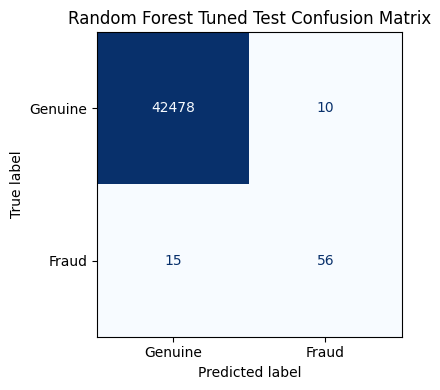

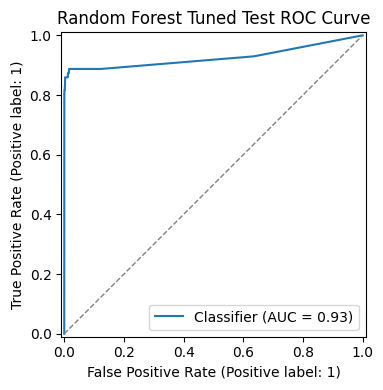

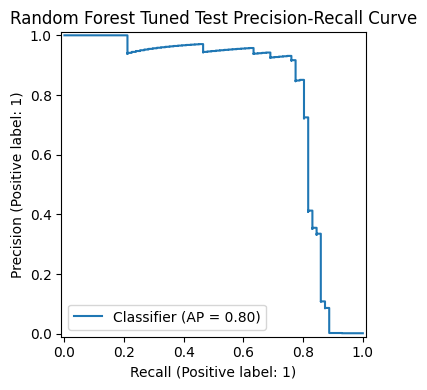

In [14]:
test_predictions = (test_scores >= selected_threshold).astype(int)
figure_prefix = OUTPUT_FIGURES_DIR / "shehab_"

fig, ax = plot_confusion_matrix(
    y_test,
    test_predictions,
    title=f"{selected_key[0]} Test Confusion Matrix",
)
fig.savefig(f"{figure_prefix}confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plot_roc_curve(
    y_test,
    test_scores,
    title=f"{selected_key[0]} Test ROC Curve",
)
fig.savefig(f"{figure_prefix}roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plot_precision_recall_curve(
    y_test,
    test_scores,
    title=f"{selected_key[0]} Test Precision-Recall Curve",
)
fig.savefig(f"{figure_prefix}precision_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 18. Random Forest Interpretation

TreeSHAP is used for the best tuned Random Forest when practical. If that is too slow or unavailable, the notebook falls back to Random Forest feature importance.

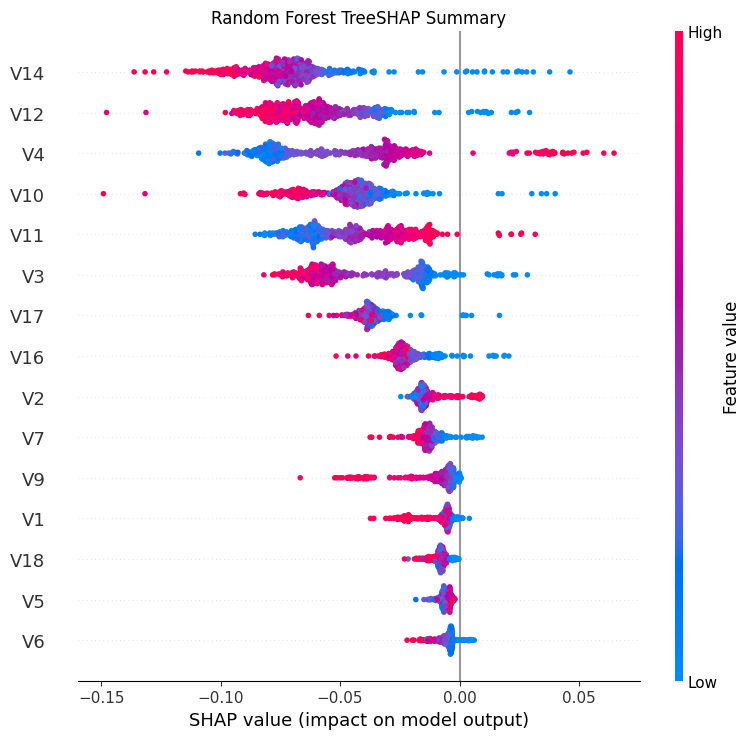

Saved Random Forest TreeSHAP summary figure.


In [15]:
rf_validation_rows = validation_results_df[validation_results_df["model"].eq("Random Forest Tuned")].copy()
if rf_validation_rows.empty:
    raise ValueError("No tuned Random Forest validation results were found.")

best_rf_row = rf_validation_rows.sort_values(["pr_auc", "mcc"], ascending=False).iloc[0]
best_rf_key = (best_rf_row["model"], best_rf_row["imbalance_strategy"])
best_rf_model = fitted_models[best_rf_key]
rf_estimator = best_rf_model.named_steps["model"]

shap_sample_size = min(500, len(X_val))
X_shap = X_val.sample(n=shap_sample_size, random_state=RANDOM_STATE)

try:
    import shap

    explainer = shap.TreeExplainer(rf_estimator)
    shap_values = explainer.shap_values(X_shap)

    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[1]
    elif np.ndim(shap_values) == 3:
        shap_values_to_plot = shap_values[:, :, 1]
    else:
        shap_values_to_plot = shap_values

    shap.summary_plot(shap_values_to_plot, X_shap, show=False, max_display=15)
    plt.title("Random Forest TreeSHAP Summary")
    plt.tight_layout()
    plt.savefig(OUTPUT_FIGURES_DIR / "shehab_random_forest_treeshap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved Random Forest TreeSHAP summary figure.")
except Exception as error:
    importances = pd.Series(rf_estimator.feature_importances_, index=X_train.columns)
    top_importances = importances.sort_values(ascending=False).head(15).sort_values()

    ax = top_importances.plot(kind="barh", figsize=(8, 5))
    ax.set_title("Random Forest Feature Importance")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.savefig(OUTPUT_FIGURES_DIR / "shehab_random_forest_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"TreeSHAP was not completed, so feature importance was used instead: {error}")

## 19. Interpretation Notes

### Which Model Performed Better?

Complete this after running the notebook with the processed datasets. Compare the validation PR-AUC, MCC, recall at 90% precision, and final test performance.

### Why PR-AUC Matters

In the Pozzolo / ULB fraud dataset, genuine transactions heavily outnumber fraudulent transactions. PR-AUC gives a clearer view of how well the model ranks fraud cases when the positive class is rare.

### Why MCC Is Useful

MCC provides a balanced single-measure check because it uses true positives, false positives, false negatives, and true negatives. This is helpful when accuracy may look strong simply because most transactions are genuine.

### Recall at 90% Precision

This metric estimates how much fraud the model can capture while keeping precision high. For fraud operations, it helps judge whether alerts are likely to be manageable and credible for review teams.

### Cross-Comparison with Group Models

After the other group results are available, compare Shehab's Logistic Regression and Random Forest results against the remaining individual models using the shared results schema.